In [1]:
import numpy as np
import globals as gl
import nibabel as nb
import os
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('default')


Base directory found: /cifs/diedrichsen/data/SensoriMotorPrediction/
Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/


In [4]:
experiment = 'smp2'
Hem = 'L'
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
r = 1
glm = 12
sn = 109

g_atlas = nb.load(os.path.join(gl.atlas_dir, f'ROI.32k.{Hem}.label.gii'))

labels = {
    ele.key: getattr(ele, 'label', '')
    for ele in g_atlas.labeltable.labels
}

y_hat_go = nb.load(os.path.join(gl.baseDir, experiment,  f'{gl.glmDir}{glm}', f'subj{sn}', f'ROI.y_hat.go.cut.ptseries.nii'))
y_filt_go = nb.load(os.path.join(gl.baseDir, experiment, f'{gl.glmDir}{glm}', f'subj{sn}', f'ROI.y_filt.go.cut.ptseries.nii'))
y_adj_go = nb.load(os.path.join(gl.baseDir, experiment, f'{gl.glmDir}{glm}',f'subj{sn}', f'ROI.y_adj.go.cut.ptseries.nii'))

y_hat_nogo = nb.load(os.path.join(gl.baseDir, experiment,  f'{gl.glmDir}{glm}', f'subj{sn}', f'ROI.y_hat.nogo.cut.ptseries.nii'))
y_filt_nogo = nb.load(os.path.join(gl.baseDir, experiment, f'{gl.glmDir}{glm}', f'subj{sn}', f'ROI.y_filt.nogo.cut.ptseries.nii'))
y_adj_nogo = nb.load(os.path.join(gl.baseDir, experiment, f'{gl.glmDir}{glm}',f'subj{sn}', f'ROI.y_adj.nogo.cut.ptseries.nii'))

fig, axs = plt.subplots(nrows=2, ncols=4, sharex=True, sharey=True, figsize=(10, 8))
for i in range(2):
    for j in range(4):

        axs[i, j].plot(y_adj_go.header.get_axis(0), y_adj_go.dataobj[:, r], color='magenta', label='go adj', ls='-')
        axs[i, j].plot(y_hat_go.header.get_axis(0), y_hat_go.dataobj[:, r], color='magenta', label='go hat', ls='--')

        axs[i, j].plot(y_adj_nogo.header.get_axis(0), y_adj_nogo.dataobj[:, r], color='forestgreen', label='nogo adj', ls='-')
        axs[i, j].plot(y_hat_nogo.header.get_axis(0), y_hat_nogo.dataobj[:, r], color='forestgreen', label='nogo hat', ls='--')

        axs[i, j].axvline(1.5, color='k', ls='-')
        axs[i, j].axvline(5.5, color='k', ls='--')

        axs[i, j].set_title(labels[r])

        r = r + 1

fig.supylabel('activation (a.u.)')
fig.supxlabel('time relative to startTRReal (TR)')
fig.suptitle(f'Activation relative to trial onset (participant: {sn}, hemisphere:{Hem}, glm:{glm})')

fig.tight_layout()

FileNotFoundError: No such file or no access: '/cifs/diedrichsen/data/SensoriMotorPrediction/smp2/glm12/subj109/ROI.y_hat.go.cut.ptseries.nii'

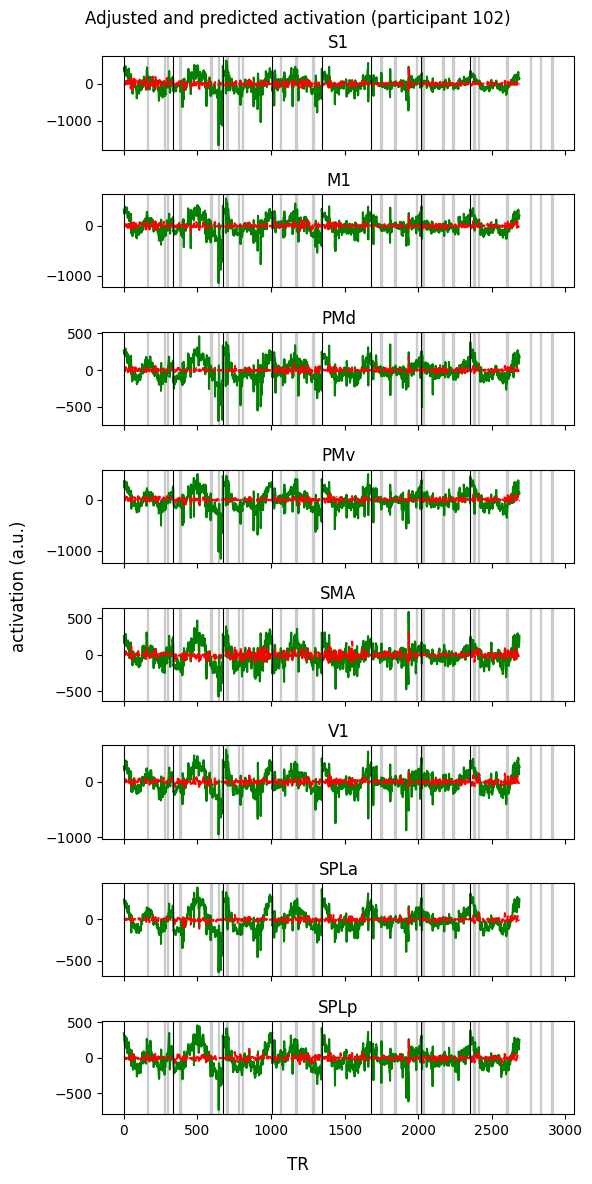

In [54]:
experiment = 'smp2'
Hem = 'L'
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
sn = 102

g_atlas = nb.load(os.path.join(gl.atlas_dir, f'ROI.32k.{Hem}.label.gii'))

labels = {
    ele.key: getattr(ele, 'label', '')
    for ele in g_atlas.labeltable.labels
}

y_raw = nb.load(os.path.join(gl.baseDir, experiment,  f'{gl.glmDir}{glm}', f'subj{sn}', f'ROI.y_raw.ptseries.nii'))
y_hat = nb.load(os.path.join(gl.baseDir, experiment,  f'{gl.glmDir}{glm}', f'subj{sn}', f'ROI.y_hat.ptseries.nii'))
y_filt = nb.load(os.path.join(gl.baseDir, experiment, f'{gl.glmDir}{glm}', f'subj{sn}', f'ROI.y_filt.ptseries.nii'))
y_adj = nb.load(os.path.join(gl.baseDir, experiment, f'{gl.glmDir}{glm}',f'subj{sn}', f'ROI.y_adj.ptseries.nii'))

dat = pd.read_csv(os.path.join(gl.baseDir, experiment, gl.behavDir, f'subj{sn}', f'{experiment}_{sn}.dat'), sep='\t')
startTimeReal = dat.startTimeReal
startTRReal = dat.startTRReal + (dat.BN - 1) * 336
iti = np.diff(startTimeReal)
start_bs = startTRReal[:-1][iti > 15000] + 8

fig, axs = plt.subplots(nrows=8, sharex=True, figsize=(6, 12))
for r, ax in enumerate(axs, start=1):

    # ax.plot(y_raw.header.get_axis(0), y_raw.dataobj[:, r], color='k', label='y_raw', ls='-')
    ax.plot(y_adj.header.get_axis(0), y_adj.dataobj[:, r], color='green', label='y_adj', ls='-')
    # ax.plot(y_filt.header.get_axis(0), y_filt.dataobj[:, r], color='blue', label='y_filt', ls='-')
    ax.plot(y_hat.header.get_axis(0), y_hat.dataobj[:, r], color='red', label='y_hat', ls='--')

    for i in np.arange(1, y_hat.shape[0],336):
        ax.axvline(i, color='k', ls='-', lw=.8)

    for i in start_bs:
        ax.axvspan(i, i+10, color='grey', alpha=0.3)

    ax.set_title(labels[r])

    r = r + 1

fig.supylabel('activation (a.u.)')
fig.supxlabel('TR')

fig.suptitle(f'Adjusted and predicted activation (participant {sn})')
fig.tight_layout()